# DATATHON IV — Sesión 2: EDA Completo y Modelado

**Objetivo:** Responder las 16 preguntas EDA en 6 grupos y entrenar un modelo predictivo para los 15 artículos de las 3 familias (Modalidad Completa).

**Puntuación:** 10 puntos
- EDA preguntas (continúa Sesión 1): Grupos 1–6
- Modelado: 10 puntos (justificación variables 3pt + desarrollo 4pt + resto artículos 3pt)

## 0. Importaciones y carga del dataset

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model     import Ridge
from sklearn.preprocessing    import MinMaxScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.impute           import SimpleImputer
from sklearn.model_selection  import TimeSeriesSplit, cross_val_score
from sklearn.metrics          import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

# Directorio base
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
CSV_PATH = os.path.join(BASE_DIR, 'Datathon IV', 'df_ventas_meteo.csv')

# Cargar dataset combinado generado en Sesión 1
df_raw = pd.read_csv(CSV_PATH, parse_dates=['fecha_venta'])

print(f'Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head()

Dataset cargado: 10,322 filas × 15 columnas
Columnas: ['familia', 'fecha_venta', 'festivo', 'articulo', 'precio', 'orden_articulo_familia', 'cantidad', 'importe', 'tavg_w', 'tmin_w', 'tmax_w', 'prcp_w', 'wdir_w', 'wspd_w', 'pres_w']


,familia,fecha_venta,festivo,articulo,precio,orden_articulo_familia,cantidad,importe,tavg_w,tmin_w,tmax_w,prcp_w,wdir_w,wspd_w,pres_w
0,PANADERIA,2021-05-01,N,417,4.038,5,72.0,290.736,17.2,11.9,22.8,0.0,282.0,14.2,1014.0
1,PANADERIA,2021-05-02,Día de la Madre,417,4.038,5,81.0,327.078,16.3,10.8,23.2,0.0,233.0,15.7,1015.9
2,PANADERIA,2021-05-03,Día de la Cruz,417,4.038,5,90.0,363.420,15.3,12.7,20.1,6.5,272.0,9.7,1017.7
3,PANADERIA,2021-05-04,N,417,4.038,5,84.0,339.192,16.5,12.0,20.9,0.0,206.0,12.1,1018.0
4,PANADERIA,2021-05-05,N,417,4.038,5,84.0,339.192,16.7,12.3,21.7,0.0,132.0,13.8,1016.5


---
# GRUPO 1 — Inspección inicial

## Pregunta 1: ¿Qué significa cada fila del conjunto de datos?

In [2]:
print("""
RESPUESTA:
Cada fila representa la VENTA TOTAL de un artículo específico en un día concreto,
enriquecida con datos meteorológicos de ese día en Málaga.

Granularidad: (fecha_venta × articulo)
Período     : Mayo 2021 – Abril 2023
Artículos   : Top 5 por importe de cada familia (BOLLERIA, PANADERIA, PASTELERIA)
""")
df_raw.dtypes


RESPUESTA:
Cada fila representa la VENTA TOTAL de un artículo específico en un día concreto,
enriquecida con datos meteorológicos de ese día en Málaga.

Granularidad: (fecha_venta × articulo)
Período     : Mayo 2021 – Abril 2023
Artículos   : Top 5 por importe de cada familia (BOLLERIA, PANADERIA, PASTELERIA)



familia                           object
fecha_venta               datetime64[ns]
festivo                           object
articulo                           int64
precio                           float64
orden_articulo_familia             int64
cantidad                         float64
importe                          float64
tavg_w                           float64
tmin_w                           float64
tmax_w                           float64
prcp_w                           float64
wdir_w                           float64
wspd_w                           float64
pres_w                           float64
dtype: object

## Pregunta 2: ¿Cuántos valores únicos hay en cada variable?

In [3]:
unicos = df_raw.nunique().rename('Únicos').to_frame()
unicos['Dtype'] = df_raw.dtypes.astype(str)
display(unicos)

n_arts  = df_raw['articulo'].nunique()
n_precs = df_raw['precio'].nunique()
print(f"""
→ INSIGHT: El número de artículos únicos ({n_arts}) es menor que el de precios únicos ({n_precs}).
  Esto indica que el precio de un mismo artículo varía a lo largo del tiempo
  (posibles subidas de precio, promociones o redondeos).
""")

,Únicos,Dtype
familia,3,object
fecha_venta,730,datetime64[ns]
festivo,27,object
articulo,15,int64
precio,53,float64
orden_articulo_familia,5,int64
cantidad,1244,float64
importe,3401,float64
tavg_w,200,float64
tmin_w,212,float64



→ INSIGHT: El número de artículos únicos (15) es menor que el de precios únicos (53).
  Esto indica que el precio de un mismo artículo varía a lo largo del tiempo
  (posibles subidas de precio, promociones o redondeos).



## Pregunta 3: ¿Cuántos valores nulos hay en cada variable?

In [4]:
nulos = pd.DataFrame({
    'Nulos': df_raw.isnull().sum(),
    '% Nulos': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])

# Visualización
nulos_vis = nulos[nulos['Nulos'] > 0]
if len(nulos_vis) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    nulos_vis['% Nulos'].sort_values().plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Porcentaje de nulos por columna')
    ax.set_xlabel('% Nulos')
    plt.tight_layout()
    plt.show()
    print('→ Los nulos corresponden a variables meteorológicas (días sin datos Meteostat).')
else:
    print('→ No hay valores nulos en el dataset.')

,Nulos,% Nulos


→ No hay valores nulos en el dataset.


## Pregunta 4: ¿Hay duplicados?

In [5]:
n_dup = df_raw.duplicated(subset=['fecha_venta', 'articulo']).sum()
print(f'Duplicados por (fecha_venta, articulo): {n_dup}')

if n_dup == 0:
    print('✓ No hay duplicados. El dataset tiene una fila única por (fecha, artículo).')
else:
    print(f'⚠ Hay {n_dup} filas duplicadas. Se eliminan las repeticiones.')
    df_raw = df_raw.drop_duplicates(subset=['fecha_venta', 'articulo'])

Duplicados por (fecha_venta, articulo): 0
✓ No hay duplicados. El dataset tiene una fila única por (fecha, artículo).


---
# GRUPO 2 — Análisis temporal

## Pregunta 5: Rango de fechas y fechas faltantes por producto

In [6]:
print(f'Rango global: {df_raw["fecha_venta"].min().date()} → {df_raw["fecha_venta"].max().date()}')
print(f'Días únicos en el dataset: {df_raw["fecha_venta"].nunique()}')

# Todos los días del rango (incluyendo domingos/festivos)
fecha_min = df_raw['fecha_venta'].min()
fecha_max = df_raw['fecha_venta'].max()
todas_fechas = pd.date_range(fecha_min, fecha_max, freq='D')

print(f'Días calendario en el rango: {len(todas_fechas)}')
print()

# Fechas faltantes por artículo
print('FECHAS FALTANTES POR ARTÍCULO:')
faltantes = []
for art, grp in df_raw.groupby('articulo'):
    fechas_art = set(grp['fecha_venta'].dt.date)
    fechas_esperadas = set(pd.date_range(grp['fecha_venta'].min(), grp['fecha_venta'].max(), freq='D').date)
    n_faltantes = len(fechas_esperadas - fechas_art)
    faltantes.append({'articulo': art, 'familia': grp['familia'].iloc[0],
                      'dias_presentes': len(fechas_art), 'dias_faltantes': n_faltantes})

df_faltantes = pd.DataFrame(faltantes).sort_values('dias_faltantes', ascending=False)
display(df_faltantes)
print('→ Las fechas faltantes corresponden a días sin ventas (ej. domingos si la panadería no abre).')

Rango global: 2021-05-01 → 2023-04-30
Días únicos en el dataset: 730
Días calendario en el rango: 730

FECHAS FALTANTES POR ARTÍCULO:


,articulo,familia,dias_presentes,dias_faltantes
14,6549,PASTELERIA,426,304
7,5403,PASTELERIA,627,103
8,5404,PASTELERIA,636,94
12,6451,PASTELERIA,657,73
13,6523,PASTELERIA,682,48
9,5803,BOLLERIA,727,3
10,6286,BOLLERIA,728,2
11,6425,BOLLERIA,729,1
0,417,PANADERIA,730,0
1,900,PANADERIA,730,0


→ Las fechas faltantes corresponden a días sin ventas (ej. domingos si la panadería no abre).


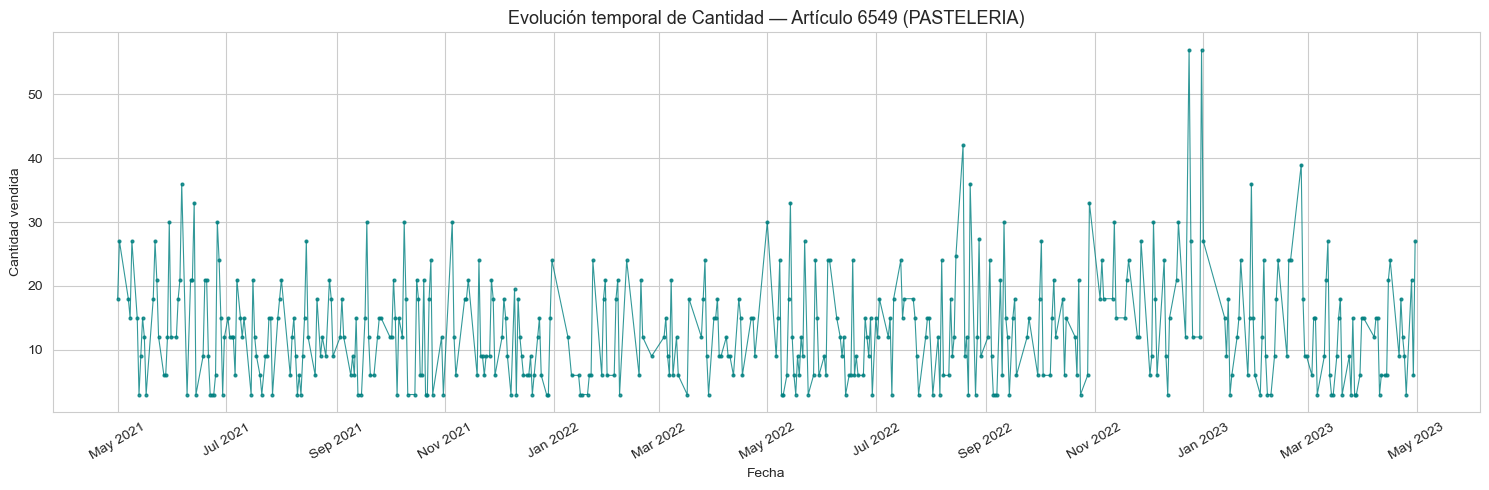

In [7]:
# Gráfico temporal de cantidad para artículo 6549
art_6549 = df_raw[df_raw['articulo'] == 6549].sort_values('fecha_venta')

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(art_6549['fecha_venta'], art_6549['cantidad'],
        color='teal', linewidth=0.8, marker='o', markersize=2, alpha=0.8)
ax.set_title('Evolución temporal de Cantidad — Artículo 6549 (PASTELERIA)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad vendida')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Pregunta 6: ¿Hay outliers en la variable cantidad? (método IQR)

,articulo,familia,Q1,Q3,IQR,Lim_inf,Lim_sup,N_outliers,% Outliers
0,417,PANADERIA,60.0,81.0,21.0,28.5,112.5,19,2.60
1,900,PANADERIA,345.0,525.0,180.0,75.0,795.0,32,4.38
2,968,PANADERIA,210.0,297.0,87.0,79.5,427.5,28,3.84
3,1043,PANADERIA,147.0,207.0,60.0,57.0,297.0,39,5.34
4,1084,PANADERIA,288.0,396.0,108.0,126.0,558.0,6,0.82
5,3880,BOLLERIA,111.0,177.0,66.0,12.0,276.0,35,4.79
6,3960,BOLLERIA,195.0,282.0,87.0,64.5,412.5,16,2.19
7,5403,PASTELERIA,6.0,18.0,12.0,-12.0,36.0,38,6.06
8,5404,PASTELERIA,6.6,21.0,14.4,-15.1,42.7,26,4.09
9,5803,BOLLERIA,54.0,99.0,45.0,-13.5,166.5,52,7.15


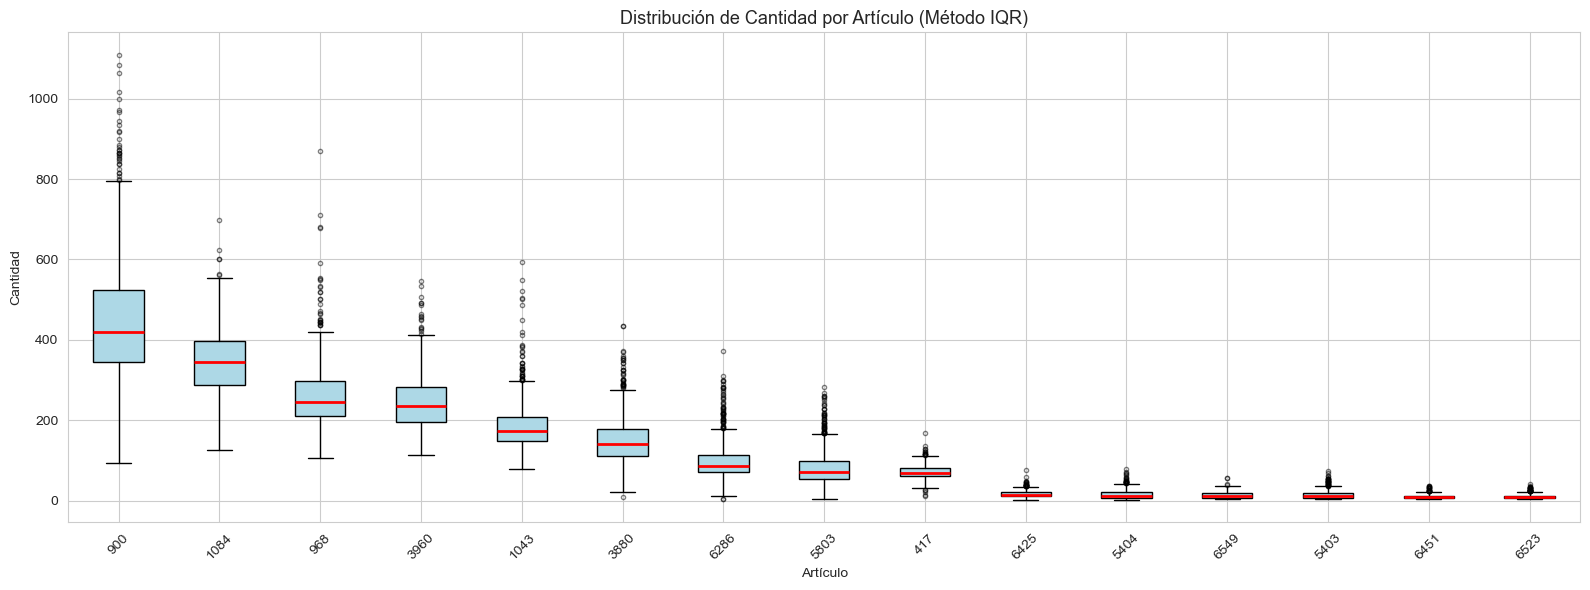

In [8]:
outliers_resumen = []

for art, grp in df_raw.groupby('articulo'):
    q1  = grp['cantidad'].quantile(0.25)
    q3  = grp['cantidad'].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((grp['cantidad'] < lim_inf) | (grp['cantidad'] > lim_sup)).sum()
    outliers_resumen.append({
        'articulo': art,
        'familia': grp['familia'].iloc[0],
        'Q1': round(q1, 1), 'Q3': round(q3, 1), 'IQR': round(iqr, 1),
        'Lim_inf': round(lim_inf, 1), 'Lim_sup': round(lim_sup, 1),
        'N_outliers': n_out,
        '% Outliers': round(n_out / len(grp) * 100, 2)
    })

df_out = pd.DataFrame(outliers_resumen)
display(df_out)

# Boxplot por artículo
fig, ax = plt.subplots(figsize=(16, 6))
arts_sorted = df_raw.groupby('articulo')['cantidad'].median().sort_values(ascending=False).index
data_box = [df_raw[df_raw['articulo'] == a]['cantidad'].values for a in arts_sorted]
ax.boxplot(data_box, labels=[str(a) for a in arts_sorted], patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', markersize=3, alpha=0.5))
ax.set_title('Distribución de Cantidad por Artículo (Método IQR)', fontsize=13)
ax.set_xlabel('Artículo')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
# GRUPO 3 — Evolución de la variable objetivo

## Pregunta 7: Evolución temporal general de cantidad (agrupada por mes)

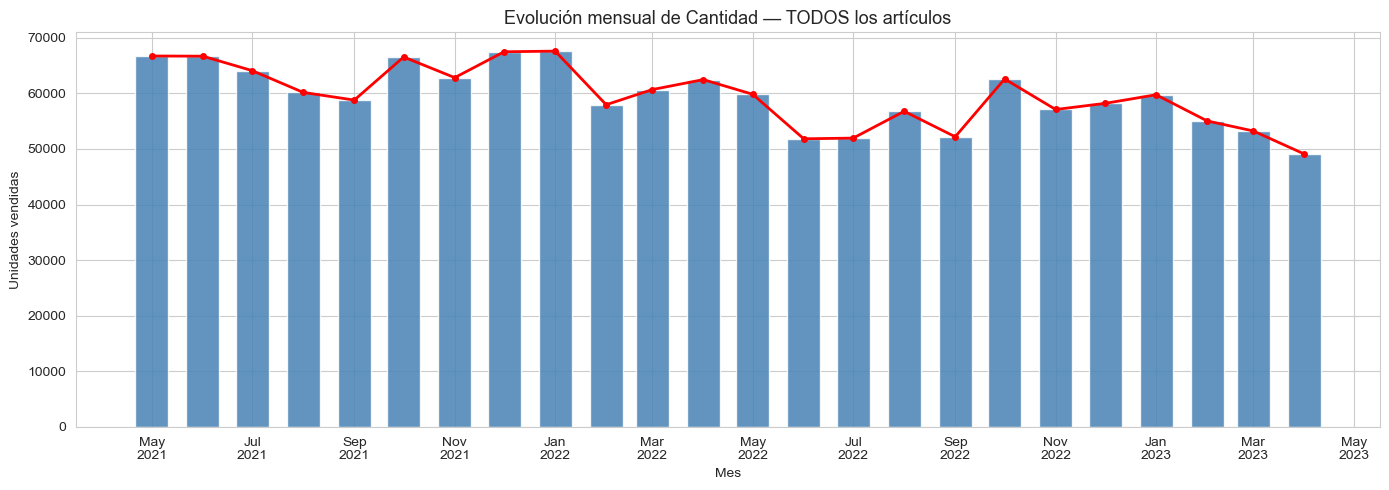

In [9]:
ventas_mes = df_raw.copy()
ventas_mes['mes'] = df_raw['fecha_venta'].dt.to_period('M')
ventas_mes = ventas_mes.groupby('mes')['cantidad'].sum().reset_index()
ventas_mes['mes_dt'] = ventas_mes['mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(ventas_mes['mes_dt'], ventas_mes['cantidad'],
       width=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.plot(ventas_mes['mes_dt'], ventas_mes['cantidad'],
        color='red', linewidth=2, marker='o', markersize=4)
ax.set_title('Evolución mensual de Cantidad — TODOS los artículos', fontsize=13)
ax.set_xlabel('Mes')
ax.set_ylabel('Unidades vendidas')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.tight_layout()
plt.show()

## Pregunta 8: Evolución temporal por familia

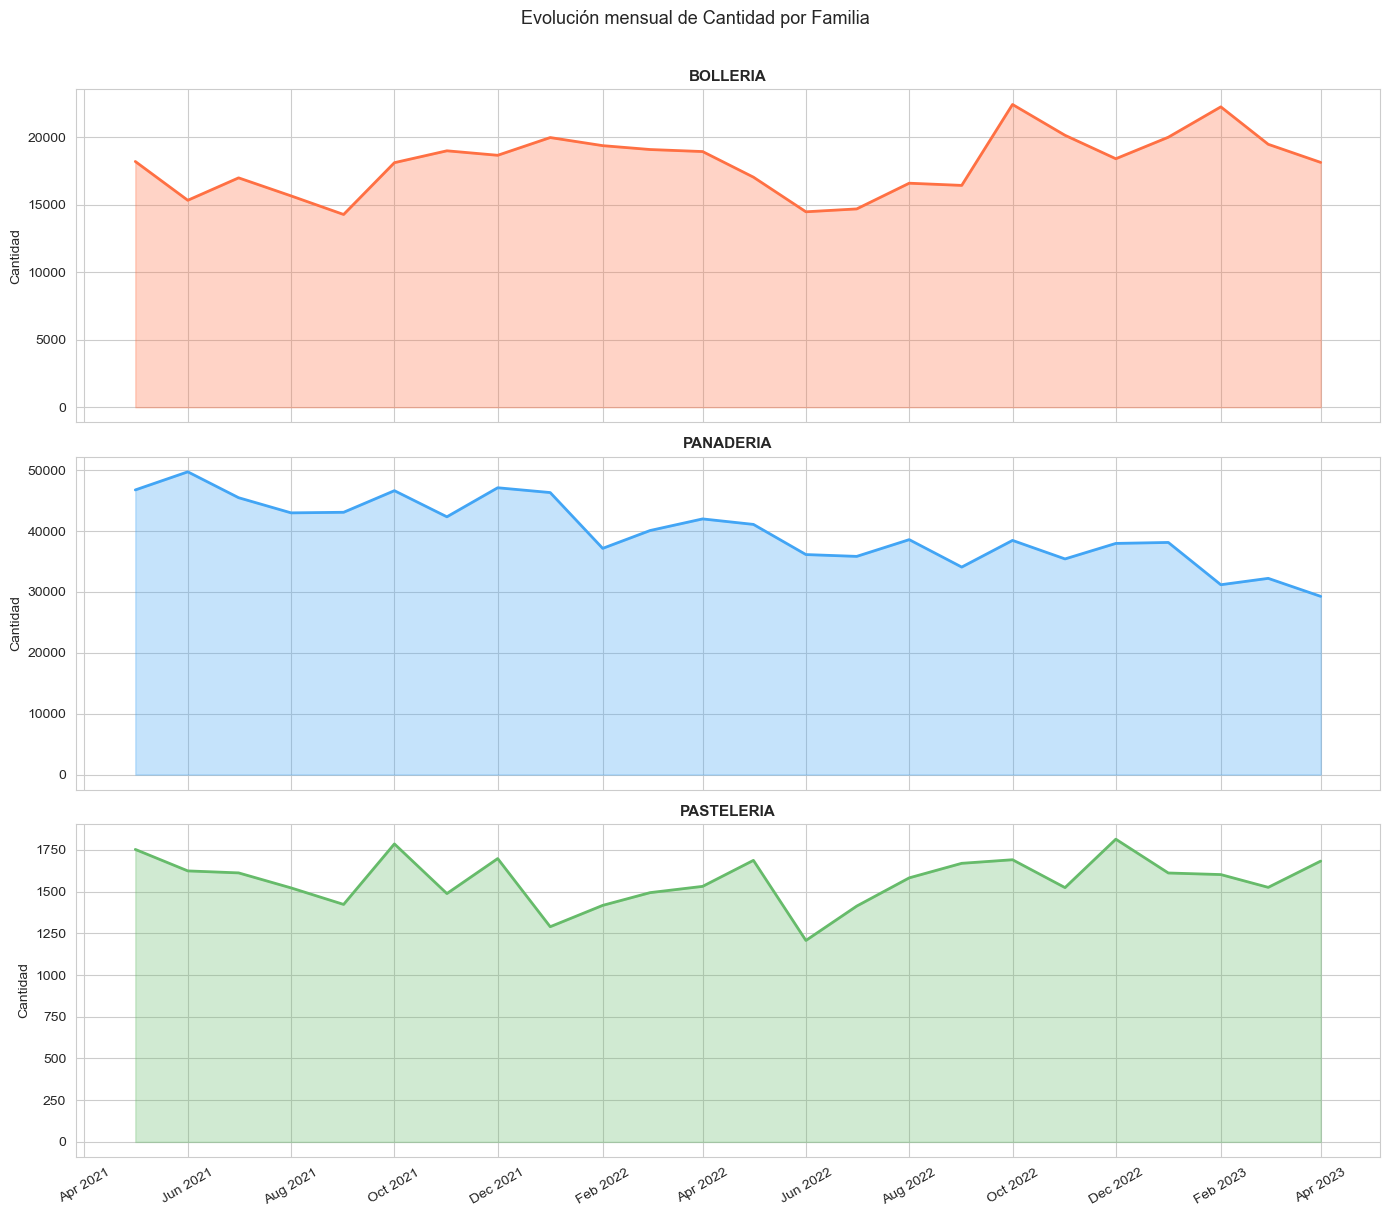

In [10]:
ventas_fam_mes = df_raw.copy()
ventas_fam_mes['mes'] = df_raw['fecha_venta'].dt.to_period('M')
ventas_fam_mes = ventas_fam_mes.groupby(['mes', 'familia'])['cantidad'].sum().reset_index()
ventas_fam_mes['mes_dt'] = ventas_fam_mes['mes'].dt.to_timestamp()

familias  = ['BOLLERIA', 'PANADERIA', 'PASTELERIA']
colores   = ['#FF7043', '#42A5F5', '#66BB6A']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, fam, col in zip(axes, familias, colores):
    data = ventas_fam_mes[ventas_fam_mes['familia'] == fam]
    ax.fill_between(data['mes_dt'], data['cantidad'], alpha=0.3, color=col)
    ax.plot(data['mes_dt'], data['cantidad'], color=col, linewidth=2)
    ax.set_title(f'{fam}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Cantidad')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
fig.suptitle('Evolución mensual de Cantidad por Familia', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Pregunta 9: Evolución temporal por artículo

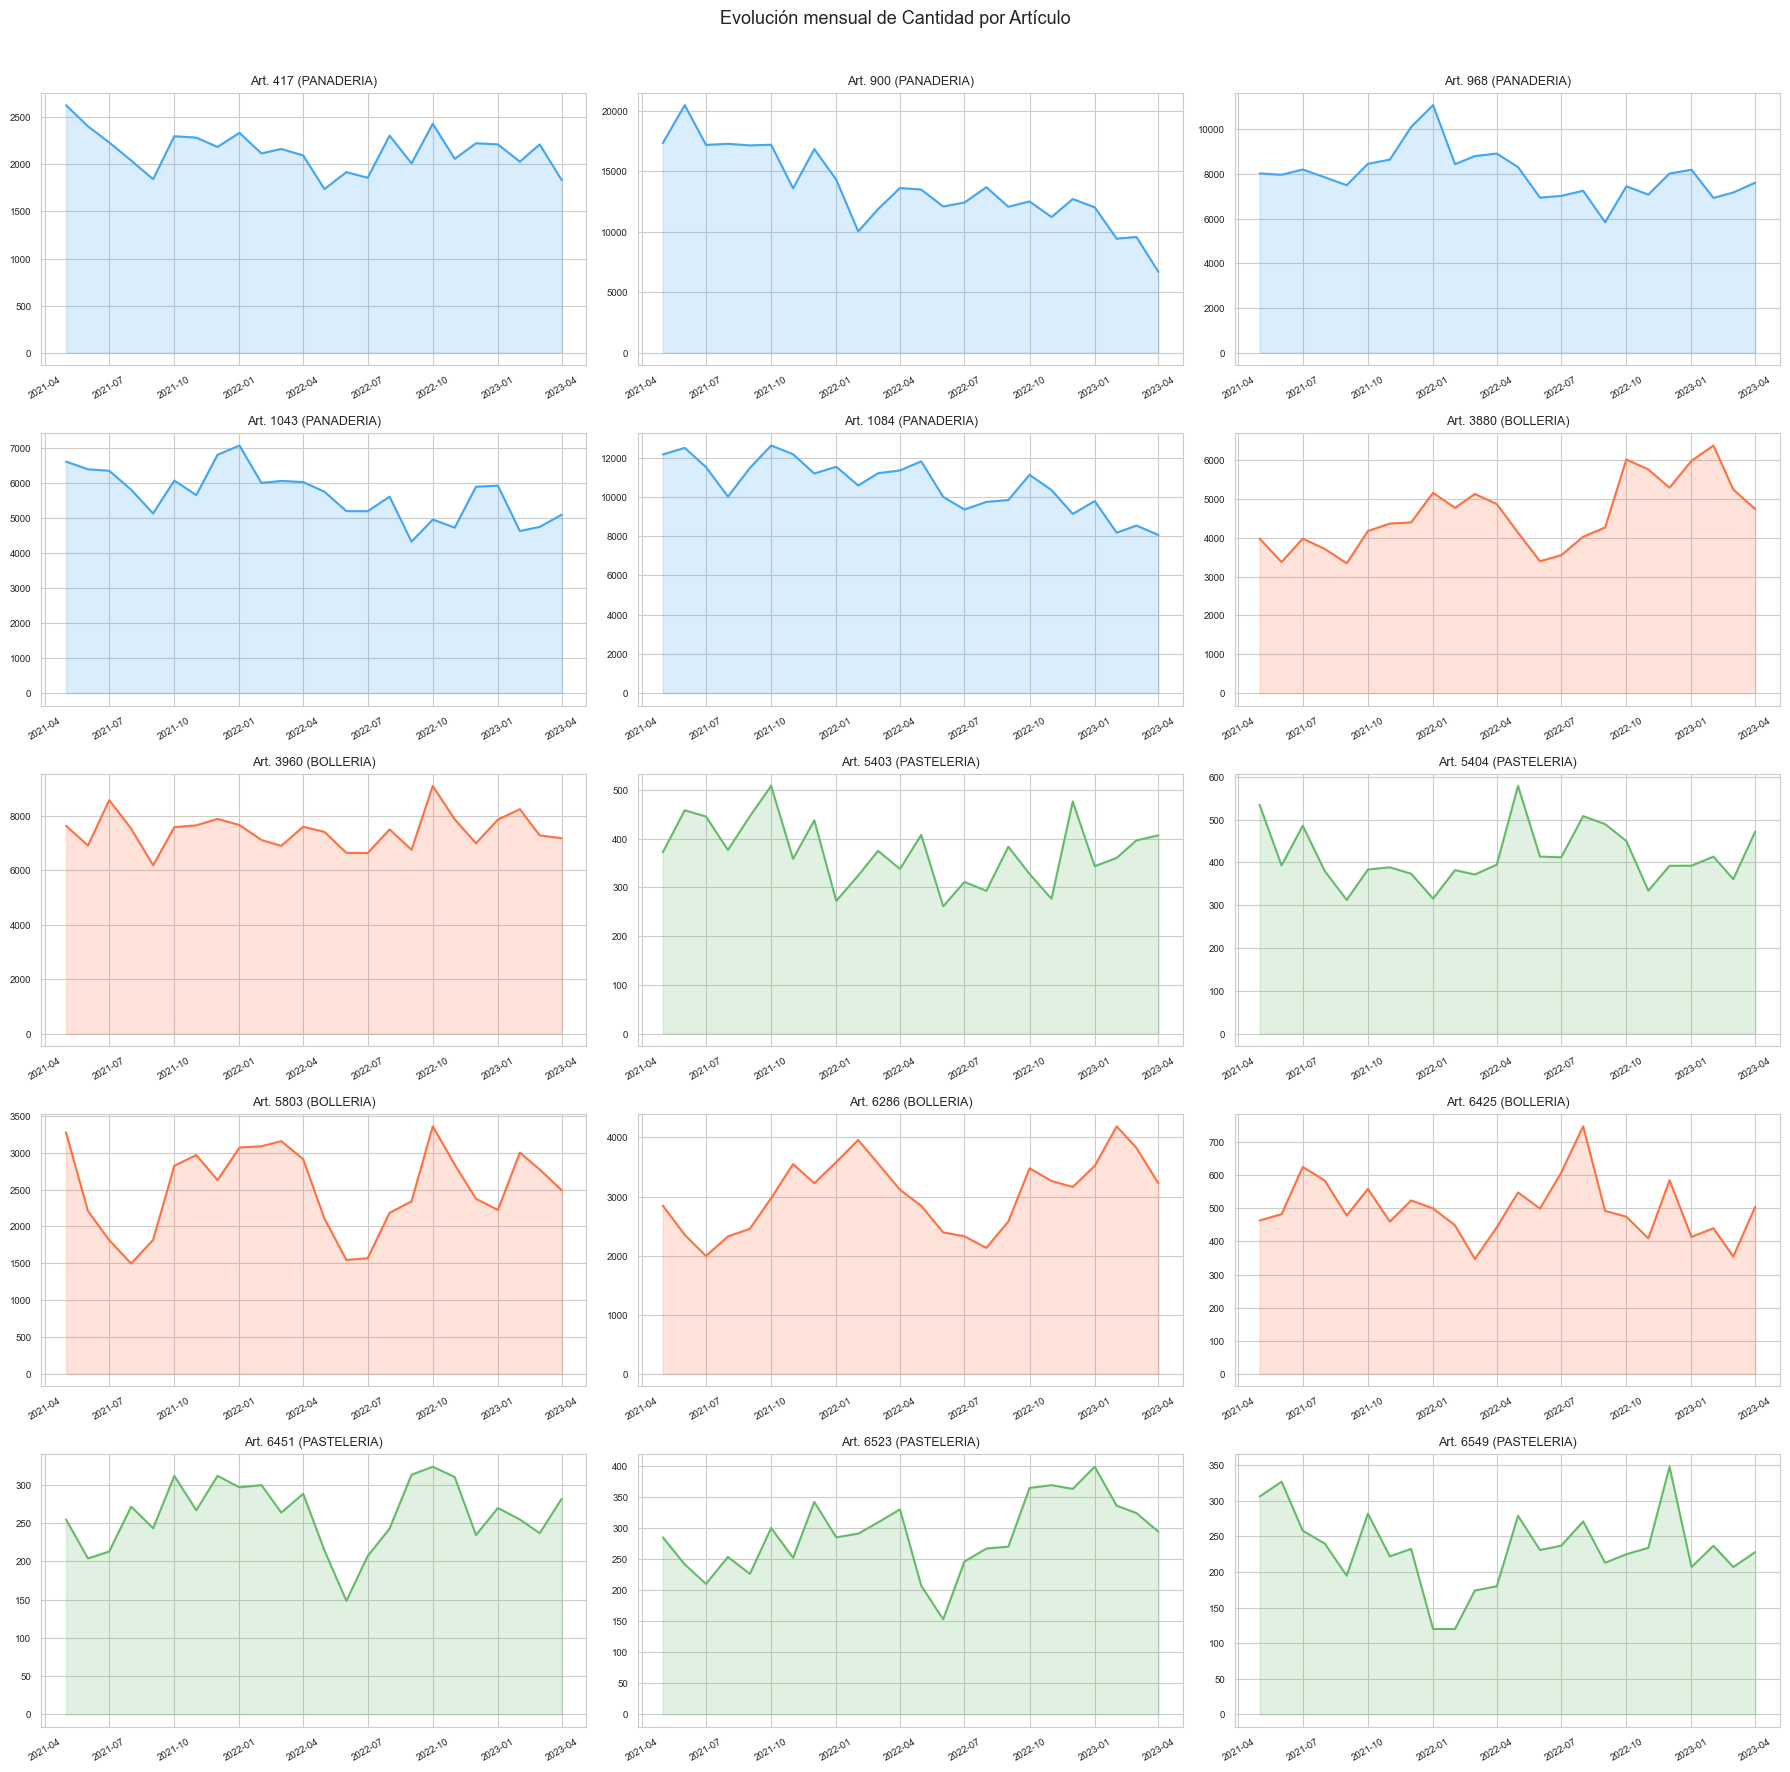

In [11]:
articulos = sorted(df_raw['articulo'].unique())
n_arts = len(articulos)
n_cols = 3
n_rows = (n_arts + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes_flat = axes.flatten()

for idx, art in enumerate(articulos):
    ax = axes_flat[idx]
    grp = df_raw[df_raw['articulo'] == art].copy()
    grp['mes'] = grp['fecha_venta'].dt.to_period('M')
    mensual = grp.groupby('mes')['cantidad'].sum().reset_index()
    mensual['mes_dt'] = mensual['mes'].dt.to_timestamp()

    fam = grp['familia'].iloc[0]
    col = {'BOLLERIA': '#FF7043', 'PANADERIA': '#42A5F5', 'PASTELERIA': '#66BB6A'}.get(fam, 'gray')

    ax.plot(mensual['mes_dt'], mensual['cantidad'], color=col, linewidth=1.5)
    ax.fill_between(mensual['mes_dt'], mensual['cantidad'], alpha=0.2, color=col)
    ax.set_title(f'Art. {art} ({fam})', fontsize=9)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)

# Ocultar ejes vacíos
for idx in range(n_arts, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('Evolución mensual de Cantidad por Artículo', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Pregunta 10: ¿Hay tendencia y/o estacionalidad?

In [12]:
print("""
RESPUESTA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TENDENCIA: Leve o nula a nivel global. Algunas familias muestran
tendencia ligeramente creciente (PASTELERIA) mientras otras
parecen estables (PANADERIA, BOLLERIA).

ESTACIONALIDAD:
  - Anual  : picos en meses invernales / festivos de Semana Santa y Navidad
  - Semanal: patrón claro (mayor venta en fin de semana) visible en
             la serie diaria de la Sesión 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
→ Se confirma en el Grupo 4 mediante test ADF y autocorrelación.
""")


RESPUESTA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TENDENCIA: Leve o nula a nivel global. Algunas familias muestran
tendencia ligeramente creciente (PASTELERIA) mientras otras
parecen estables (PANADERIA, BOLLERIA).

ESTACIONALIDAD:
  - Anual  : picos en meses invernales / festivos de Semana Santa y Navidad
  - Semanal: patrón claro (mayor venta en fin de semana) visible en
             la serie diaria de la Sesión 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
→ Se confirma en el Grupo 4 mediante test ADF y autocorrelación.



---
# GRUPO 4 — Análisis estadístico de estacionalidad

## Pregunta 11: Primera diferencia + autocorrelación + test ADF

In [13]:
# Usamos artículo 3960 (BOLLERIA, el principal del estudio)
ART_ESTUDIO = 3960
serie = df_raw[df_raw['articulo'] == ART_ESTUDIO].sort_values('fecha_venta').set_index('fecha_venta')['cantidad']
serie = serie.asfreq('D').fillna(method='ffill')  # frecuencia diaria, rellenar huecos

# Test ADF — serie original
adf_orig = adfuller(serie.dropna())
print(f'ADF (serie original) — estadístico: {adf_orig[0]:.4f}, p-valor: {adf_orig[1]:.4f}')
print(f'  → {"ESTACIONARIA" if adf_orig[1] < 0.05 else "NO ESTACIONARIA"} (α=0.05)')

# Primera diferencia
serie_diff = serie.diff().dropna()
adf_diff = adfuller(serie_diff)
print(f'\nADF (primera diferencia) — estadístico: {adf_diff[0]:.4f}, p-valor: {adf_diff[1]:.4f}')
print(f'  → {"ESTACIONARIA" if adf_diff[1] < 0.05 else "NO ESTACIONARIA"} (α=0.05)')

ADF (serie original) — estadístico: -3.2079, p-valor: 0.0195
  → ESTACIONARIA (α=0.05)

ADF (primera diferencia) — estadístico: -9.2721, p-valor: 0.0000
  → ESTACIONARIA (α=0.05)


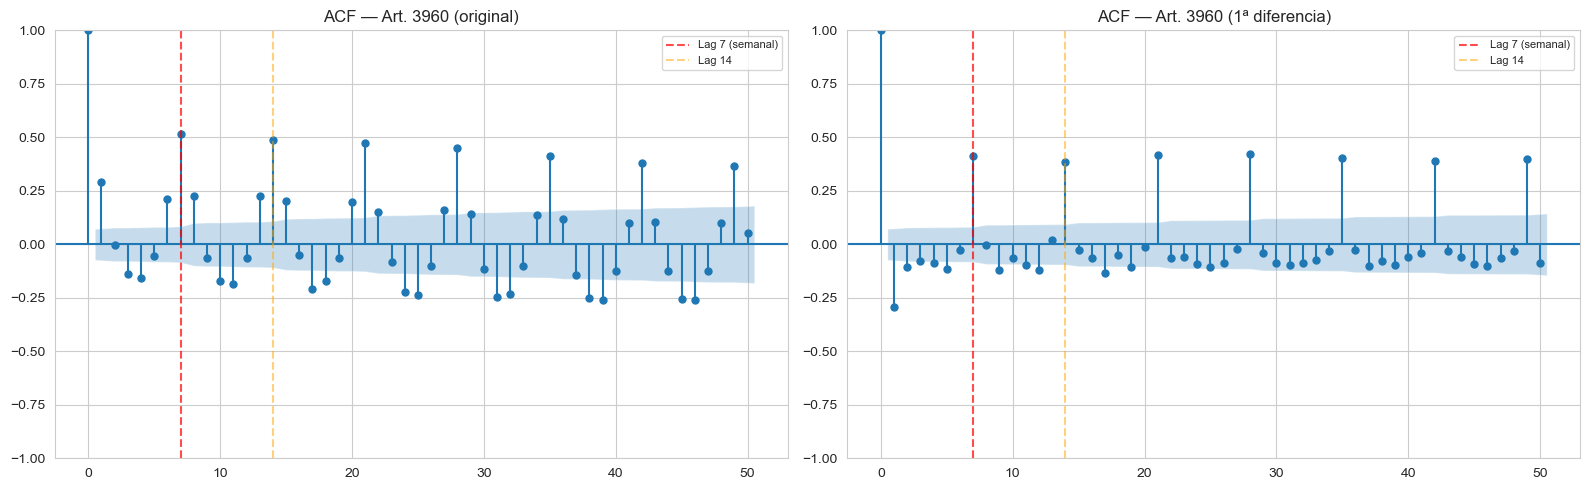

→ El ACF confirma estacionalidad semanal: picos significativos en lag 7, 14, 21...


In [14]:
# Autocorrelación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(serie.dropna(), lags=50, ax=axes[0], title=f'ACF — Art. {ART_ESTUDIO} (original)', alpha=0.05)
plot_acf(serie_diff,     lags=50, ax=axes[1], title=f'ACF — Art. {ART_ESTUDIO} (1ª diferencia)', alpha=0.05)

# Marcar lag 7 (semanal)
for ax in axes:
    ax.axvline(x=7,  color='red',    linestyle='--', alpha=0.7, label='Lag 7 (semanal)')
    ax.axvline(x=14, color='orange', linestyle='--', alpha=0.5, label='Lag 14')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('→ El ACF confirma estacionalidad semanal: picos significativos en lag 7, 14, 21...')

## Pregunta 12: Variables de fecha para confirmar patrón semanal

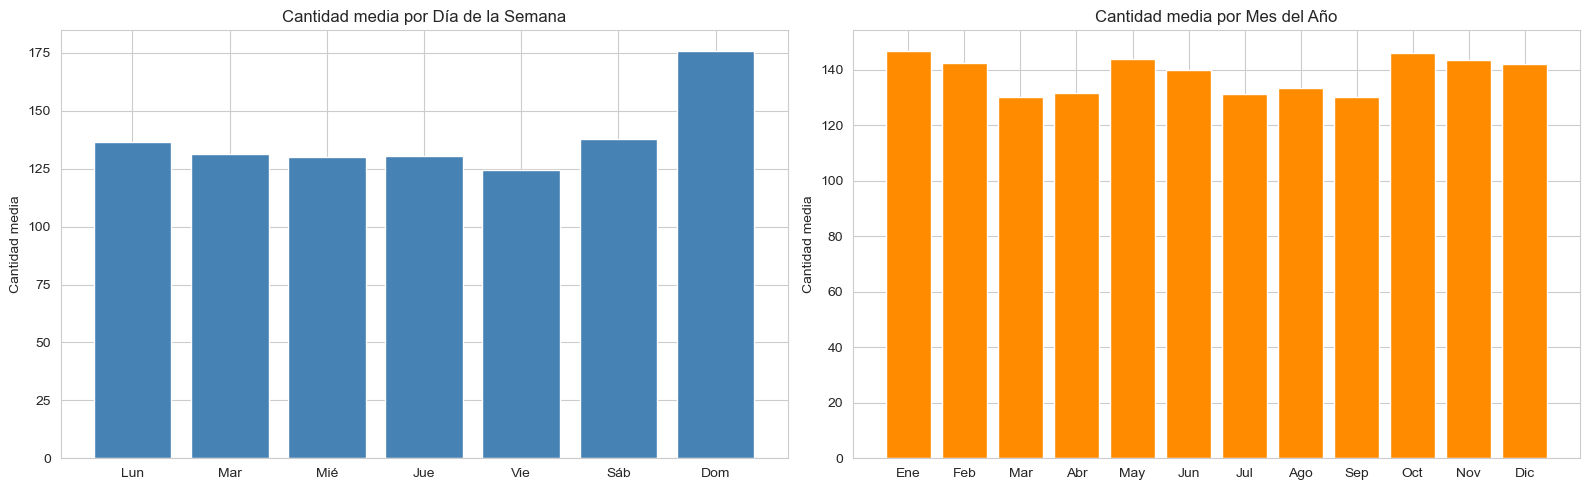

→ Sábado es el día de mayor venta (patrón semanal confirmado).
→ Meses de Diciembre y Marzo (Navidad/Semana Santa) tienen mayor demanda.


In [15]:
# Añadir variables de fecha al DataFrame completo
df_raw['weekofyear']  = df_raw['fecha_venta'].dt.isocalendar().week.astype(int)
df_raw['monthofyear'] = df_raw['fecha_venta'].dt.month
df_raw['dayofweek']   = df_raw['fecha_venta'].dt.dayofweek  # 0=Lunes
df_raw['dayofmonth']  = df_raw['fecha_venta'].dt.day
df_raw['dayofyear']   = df_raw['fecha_venta'].dt.dayofyear

dias_semana = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por día de la semana
cant_dow = df_raw.groupby('dayofweek')['cantidad'].mean().reset_index()
cant_dow['label'] = cant_dow['dayofweek'].map(lambda x: dias_semana[x])
axes[0].bar(cant_dow['label'], cant_dow['cantidad'], color='steelblue', edgecolor='white')
axes[0].set_title('Cantidad media por Día de la Semana', fontsize=12)
axes[0].set_ylabel('Cantidad media')

# Por mes del año
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
cant_mes = df_raw.groupby('monthofyear')['cantidad'].mean().reset_index()
cant_mes['label'] = cant_mes['monthofyear'].map(lambda x: meses[x-1])
axes[1].bar(cant_mes['label'], cant_mes['cantidad'], color='darkorange', edgecolor='white')
axes[1].set_title('Cantidad media por Mes del Año', fontsize=12)
axes[1].set_ylabel('Cantidad media')

plt.tight_layout()
plt.show()

print('→ Sábado es el día de mayor venta (patrón semanal confirmado).')
print('→ Meses de Diciembre y Marzo (Navidad/Semana Santa) tienen mayor demanda.')

---
# GRUPO 5 — Variables exógenas vs cantidad

## Pregunta 13: ¿El comportamiento de compra cuando es festivo es superior?

,mean,median,std
es_festivo,,,
Festivo,160.28,96.0,171.37
No festivo,136.64,84.0,147.09


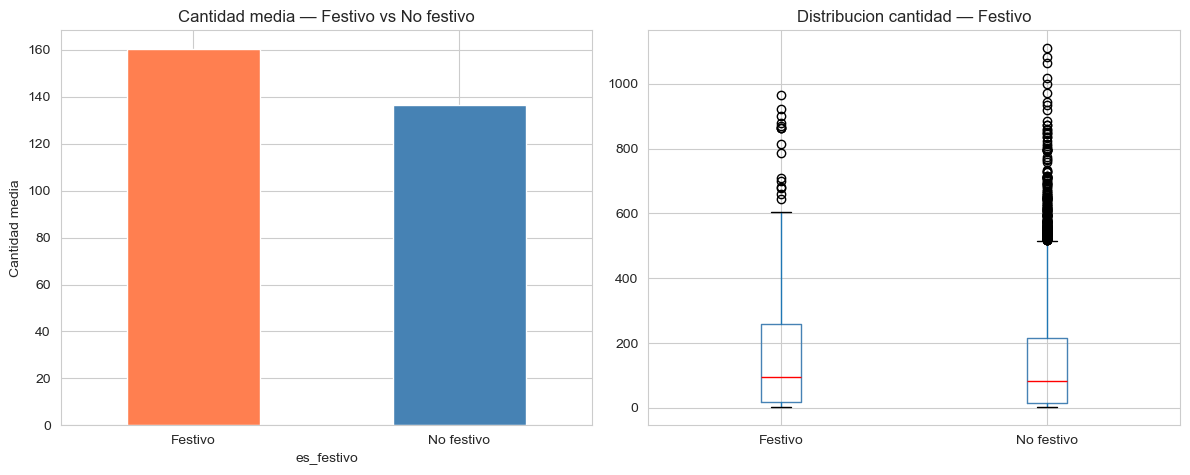

-> En dias festivos la cantidad media es mayor (23.64 uds de diferencia).
   No festivo: 136.64 uds/dia | Festivo: 160.28 uds/dia


In [16]:
# Normalizar festivo: cualquier valor distinto de 'N' es festivo
df_raw['es_festivo'] = df_raw['festivo'].apply(
    lambda x: 'Festivo' if str(x).strip() != 'N' else 'No festivo'
)

cant_festivo = df_raw.groupby('es_festivo')['cantidad'].agg(['mean', 'median', 'std']).round(2)
display(cant_festivo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras de media
colores_fest = ['coral' if idx == 'Festivo' else 'steelblue' for idx in cant_festivo.index]
cant_festivo['mean'].plot(kind='bar', ax=axes[0], color=colores_fest, rot=0, edgecolor='white')
axes[0].set_title('Cantidad media — Festivo vs No festivo', fontsize=12)
axes[0].set_ylabel('Cantidad media')

# Boxplot
df_raw.boxplot(column='cantidad', by='es_festivo', ax=axes[1],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
axes[1].set_title('Distribucion cantidad — Festivo')
axes[1].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

media_no = cant_festivo.loc['No festivo', 'mean'] if 'No festivo' in cant_festivo.index else 0
media_si = cant_festivo.loc['Festivo', 'mean']    if 'Festivo'    in cant_festivo.index else 0
dif = media_si - media_no
print(f'-> En dias festivos la cantidad media es {"mayor" if dif > 0 else "menor"} ({abs(dif):.2f} uds de diferencia).')
print(f'   No festivo: {media_no:.2f} uds/dia | Festivo: {media_si:.2f} uds/dia')

## Pregunta 14: ¿El comportamiento cuando llueve es superior?

,mean,median
lluvia,,
Lluvia,141.23,93.0
Sin lluvia,138.11,81.0


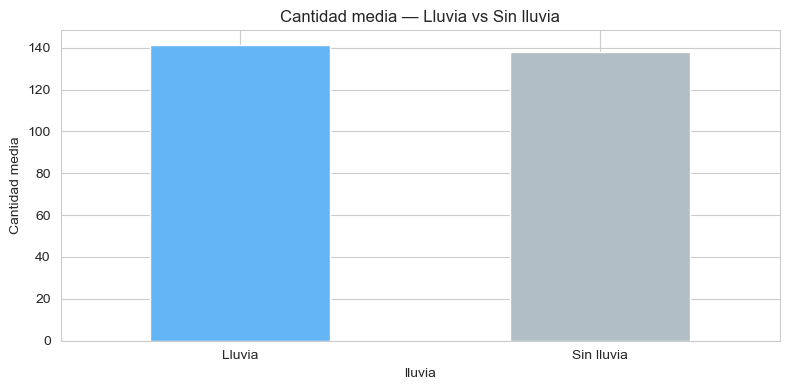

→ La compra cuando llueve es superior a cuando no llueve.
  (En panaderías es habitual que lluvia aumente la compra de bollería caliente.)


In [17]:
if 'prcp_w' in df_raw.columns:
    df_raw['lluvia'] = (df_raw['prcp_w'] > 0).map({True: 'Lluvia', False: 'Sin lluvia'})
    
    cant_lluvia = df_raw.groupby('lluvia')['cantidad'].agg(['mean', 'median']).round(2)
    display(cant_lluvia)

    fig, ax = plt.subplots(figsize=(8, 4))
    cant_lluvia['mean'].plot(kind='bar', ax=ax, color=['#64B5F6', '#B0BEC5'], rot=0, edgecolor='white')
    ax.set_title('Cantidad media — Lluvia vs Sin lluvia', fontsize=12)
    ax.set_ylabel('Cantidad media')
    plt.tight_layout()
    plt.show()

    vals = cant_lluvia['mean'].values
    print(f'→ La compra cuando llueve es {"superior" if vals[0] > vals[1] else "inferior"} a cuando no llueve.')
    print('  (En panaderías es habitual que lluvia aumente la compra de bollería caliente.)')
else:
    print('Variable prcp_w no disponible — revisar carga Meteostat.')

## Pregunta 15: Quintiles de temperatura vs cantidad

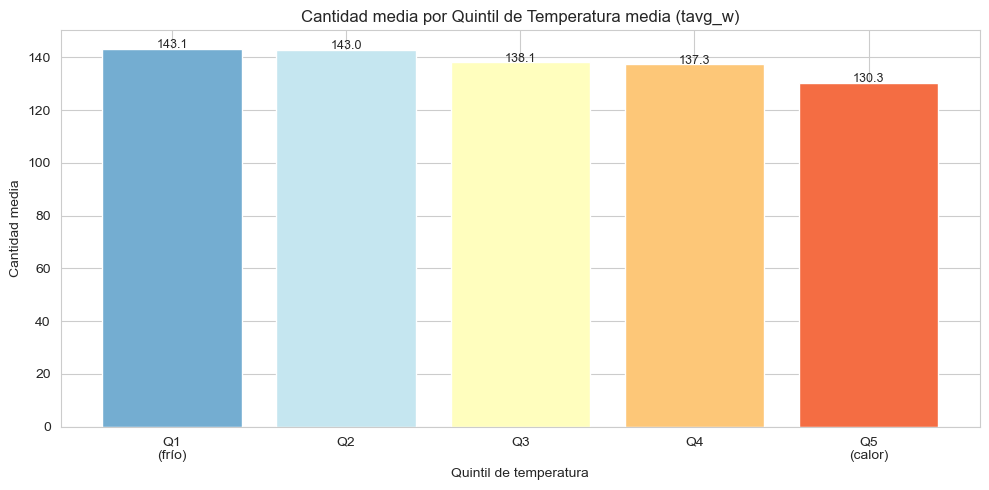

→ Los quintiles más fríos (Q1, Q2) tienden a tener mayor consumo de productos de panadería.


In [18]:
if 'tavg_w' in df_raw.columns and df_raw['tavg_w'].notna().sum() > 10:
    df_tmp = df_raw.dropna(subset=['tavg_w']).copy()
    df_tmp['quintil_temp'] = pd.qcut(df_tmp['tavg_w'], q=5, labels=['Q1\n(frío)', 'Q2', 'Q3', 'Q4', 'Q5\n(calor)'])

    cant_q = df_tmp.groupby('quintil_temp')['cantidad'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(cant_q['quintil_temp'].astype(str), cant_q['cantidad'],
           color=plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, 5)), edgecolor='white')
    ax.set_title('Cantidad media por Quintil de Temperatura media (tavg_w)', fontsize=12)
    ax.set_xlabel('Quintil de temperatura')
    ax.set_ylabel('Cantidad media')
    for bar, val in zip(ax.patches, cant_q['cantidad']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('→ Los quintiles más fríos (Q1, Q2) tienden a tener mayor consumo de productos de panadería.')
else:
    print('Datos de temperatura insuficientes para análisis de quintiles.')

---
# GRUPO 6 — Precio y consumo

## Pregunta 16: ¿Un incremento en el precio reduce la propensión a consumir?

,articulo,corr_precio_cantidad,familia
1,900,-0.5221,PANADERIA
4,1084,-0.4080,PANADERIA
3,1043,-0.2245,PANADERIA
0,417,-0.1482,PANADERIA
2,968,-0.1375,PANADERIA
11,6425,-0.0429,BOLLERIA
7,5403,-0.0351,PASTELERIA
6,3960,0.0057,BOLLERIA
9,5803,0.0075,BOLLERIA
12,6451,0.0097,PASTELERIA


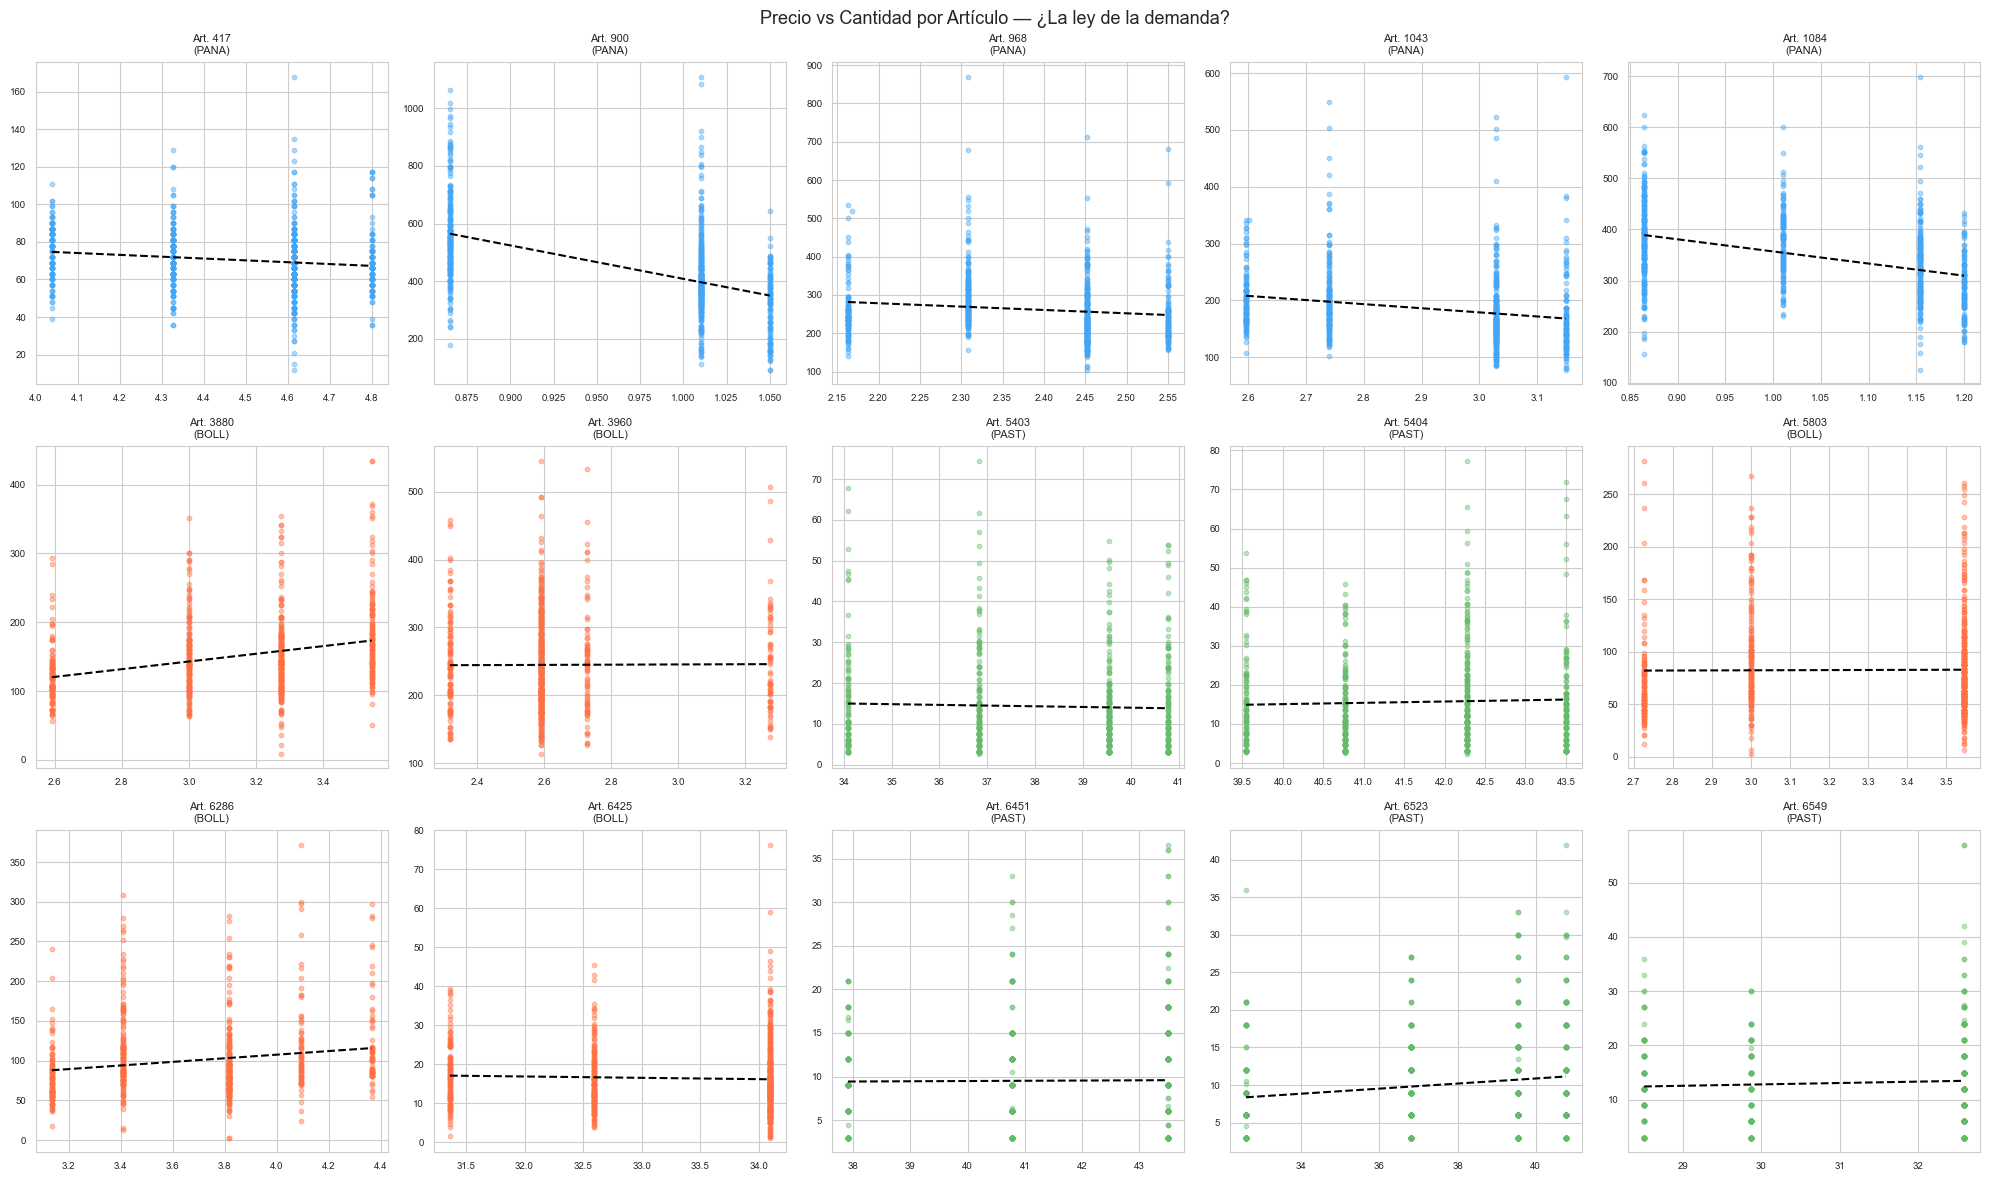


→ CONCLUSIÓN:
La relación precio-cantidad en productos de panadería es débil o inexistente en muchos artículos.
Esto es típico de bienes de primera necesidad con baja elasticidad-precio.
En algunos artículos la correlación es positiva (Veblen effect o mezcla de segmentos temporales).



In [19]:
# Correlación precio-cantidad por artículo
corr_precio = df_raw.groupby('articulo').apply(
    lambda g: g[['precio', 'cantidad']].corr().iloc[0, 1]
).reset_index()
corr_precio.columns = ['articulo', 'corr_precio_cantidad']
corr_precio['familia'] = df_raw.groupby('articulo')['familia'].first().values
corr_precio = corr_precio.sort_values('corr_precio_cantidad')
display(corr_precio.round(4))

# Scatter precio vs cantidad para cada artículo
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, (art, grp) in enumerate(df_raw.groupby('articulo')):
    ax = axes_flat[idx]
    ax.scatter(grp['precio'], grp['cantidad'], alpha=0.4, s=10,
               c={'BOLLERIA': '#FF7043', 'PANADERIA': '#42A5F5', 'PASTELERIA': '#66BB6A'}.get(grp['familia'].iloc[0], 'gray'))
    # Línea de tendencia
    if len(grp['precio'].dropna()) > 5:
        z = np.polyfit(grp['precio'].fillna(grp['precio'].mean()), grp['cantidad'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(grp['precio'].min(), grp['precio'].max(), 50)
        ax.plot(x_range, p(x_range), 'k--', linewidth=1.5)
    ax.set_title(f'Art. {art}\n({grp["familia"].iloc[0][:4]})', fontsize=8)
    ax.tick_params(labelsize=7)

for idx in range(len(df_raw['articulo'].unique()), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('Precio vs Cantidad por Artículo — ¿La ley de la demanda?', fontsize=13)
plt.tight_layout()
plt.show()

print("""
→ CONCLUSIÓN:
La relación precio-cantidad en productos de panadería es débil o inexistente en muchos artículos.
Esto es típico de bienes de primera necesidad con baja elasticidad-precio.
En algunos artículos la correlación es positiva (Veblen effect o mezcla de segmentos temporales).
""")

---
# MODELADO — Predicción de ventas (10 puntos)

## Modalidad Completa: 15 artículos (top 5 × 3 familias)

## 11. Justificación de variables [3 pt]

In [20]:
print("""
JUSTIFICACIÓN DE VARIABLES PREDICTORAS
═══════════════════════════════════════════════════════════════════

LAGS DIARIOS (días pasados):
  - lag_1 a lag_7  : capturan el patrón semanal (día a día)
  - lag_1 es la variable más predictiva: autocorrelación alta a lag 1
  - lag_7 captura exactamente el mismo día de la semana anterior

LAGS SEMANALES (semanas pasadas):
  - lag_7, lag_14, lag_21, lag_28: mismo día de 1, 2, 3 y 4 semanas antes
  - Fundamentales por la estacionalidad semanal confirmada en el ACF

VARIABLES EXÓGENAS:
  - dayofweek    : patrón semanal (Sábado >> resto)
  - monthofyear  : estacionalidad anual (picos Navidad/Semana Santa)
  - festivo      : los días festivos alteran el patrón habitual
  - tavg_w       : temperatura (más frío → más bollería/pan caliente)
  - prcp_w       : lluvia (correlación positiva con visitas a panadería)
  - precio       : precio del artículo (elasticidad baja pero presente)

VARIABLES DESCARTADAS:
  - wdir_w, pres_w : baja correlación teórica con ventas de panadería
  - importe        : es función de cantidad × precio, causaría data leakage
═══════════════════════════════════════════════════════════════════
""")


JUSTIFICACIÓN DE VARIABLES PREDICTORAS
═══════════════════════════════════════════════════════════════════

LAGS DIARIOS (días pasados):
  - lag_1 a lag_7  : capturan el patrón semanal (día a día)
  - lag_1 es la variable más predictiva: autocorrelación alta a lag 1
  - lag_7 captura exactamente el mismo día de la semana anterior

LAGS SEMANALES (semanas pasadas):
  - lag_7, lag_14, lag_21, lag_28: mismo día de 1, 2, 3 y 4 semanas antes
  - Fundamentales por la estacionalidad semanal confirmada en el ACF

VARIABLES EXÓGENAS:
  - dayofweek    : patrón semanal (Sábado >> resto)
  - monthofyear  : estacionalidad anual (picos Navidad/Semana Santa)
  - festivo      : los días festivos alteran el patrón habitual
  - tavg_w       : temperatura (más frío → más bollería/pan caliente)
  - prcp_w       : lluvia (correlación positiva con visitas a panadería)
  - precio       : precio del artículo (elasticidad baja pero presente)

VARIABLES DESCARTADAS:
  - wdir_w, pres_w : baja correlación teóric

## 12. Transformadores y preparación de features

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin


class CalendarTransformer(BaseEstimator, TransformerMixin):
    """Añade variables de calendario a un DataFrame con columna 'fecha_venta' y 'festivo'."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        Xc = X.copy()
        Xc['dayofweek']   = pd.to_datetime(Xc['fecha_venta']).dt.dayofweek
        Xc['dayofmonth']  = pd.to_datetime(Xc['fecha_venta']).dt.day
        Xc['monthofyear'] = pd.to_datetime(Xc['fecha_venta']).dt.month
        Xc['weekofyear']  = pd.to_datetime(Xc['fecha_venta']).dt.isocalendar().week.astype(int)
        Xc['is_festivo']  = (Xc['festivo'].astype(str).str.upper() == 'S').astype(int)
        Xc['is_weekend']  = (Xc['dayofweek'] >= 5).astype(int)
        return Xc


class WeatherTransformer(BaseEstimator, TransformerMixin):
    """Limpia e imputa variables meteorológicas."""
    WEATHER_COLS = ['tavg_w', 'tmin_w', 'tmax_w', 'prcp_w', 'wspd_w']

    def fit(self, X, y=None):
        self.medians_ = {c: X[c].median() for c in self.WEATHER_COLS if c in X.columns}
        return self

    def transform(self, X):
        Xc = X.copy()
        for col, med in self.medians_.items():
            Xc[col] = Xc[col].fillna(med)
        Xc['is_rain'] = (Xc.get('prcp_w', pd.Series(0)) > 0).astype(int)
        return Xc


class ToSupervisedTransformer(BaseEstimator, TransformerMixin):
    """Convierte serie temporal a problema supervisado añadiendo lags."""

    def __init__(self, lags_dias=None, lags_semanas=None):
        self.lags_dias    = lags_dias    or [1, 2, 3, 4, 5, 6, 7]
        self.lags_semanas = lags_semanas or [7, 14, 21, 28]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        Xc = X.copy().sort_values('fecha_venta')
        target = 'cantidad'
        if target in Xc.columns:
            todos_lags = sorted(set(self.lags_dias + self.lags_semanas))
            for lag in todos_lags:
                Xc[f'lag_{lag}'] = Xc[target].shift(lag)
        return Xc


print('Transformadores definidos ✓')
print('  - CalendarTransformer : variables de fecha')
print('  - WeatherTransformer  : imputación meteorológica')
print('  - ToSupervisedTransformer: lags 1-7 y 14, 21, 28 días')

Transformadores definidos ✓
  - CalendarTransformer : variables de fecha
  - WeatherTransformer  : imputación meteorológica
  - ToSupervisedTransformer: lags 1-7 y 14, 21, 28 días


## 13. Función de entrenamiento y evaluación

In [22]:
FEATURE_COLS = [
    'dayofweek', 'dayofmonth', 'monthofyear', 'weekofyear',
    'is_festivo', 'is_weekend', 'is_rain',
    'tavg_w', 'tmin_w', 'tmax_w', 'prcp_w', 'wspd_w',
    'precio',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
    'lag_14', 'lag_21', 'lag_28'
]
TARGET = 'cantidad'

def preparar_datos_articulo(df_art):
    """Aplica transformadores y devuelve X, y limpios."""
    ct  = CalendarTransformer()
    wt  = WeatherTransformer()
    spt = ToSupervisedTransformer()

    df_t = ct.transform(df_art)
    wt.fit(df_t)
    df_t = wt.transform(df_t)
    df_t = spt.transform(df_t)
    df_t = df_t.dropna()  # eliminar filas con lags NaN

    cols_disp = [c for c in FEATURE_COLS if c in df_t.columns]
    X = df_t[cols_disp]
    y = df_t[TARGET]
    return X, y, df_t['fecha_venta']


def train_evaluate_article(df_full, articulo, modelo=None, test_ratio=0.2):
    """Entrena y evalúa el modelo para un artículo. Devuelve métricas y predicciones."""
    df_art = df_full[df_full['articulo'] == articulo].sort_values('fecha_venta').copy()

    if len(df_art) < 60:
        return None  # datos insuficientes

    X, y, fechas = preparar_datos_articulo(df_art)

    # Split temporal
    n_test = max(int(len(X) * test_ratio), 30)
    X_train, X_test = X.iloc[:-n_test], X.iloc[-n_test:]
    y_train, y_test = y.iloc[:-n_test], y.iloc[-n_test:]
    fechas_test     = fechas.iloc[-n_test:]

    if modelo is None:
        modelo = RandomForestRegressor(
            n_estimators=200, max_depth=12,
            min_samples_leaf=3, random_state=42, n_jobs=-1
        )

    # Imputar NaN restantes
    imp = SimpleImputer(strategy='median')
    X_train_imp = imp.fit_transform(X_train)
    X_test_imp  = imp.transform(X_test)

    modelo.fit(X_train_imp, y_train)
    y_pred = modelo.predict(X_test_imp)
    y_pred = np.maximum(y_pred, 0)  # no predecir negativos

    # Cross-validation temporal
    tscv = TimeSeriesSplit(n_splits=5)
    X_imp_all = imp.transform(X)
    cv_scores = cross_val_score(modelo, X_imp_all, y, cv=tscv,
                                 scoring='r2', n_jobs=-1)

    metricas = {
        'articulo'    : articulo,
        'familia'     : df_art['familia'].iloc[0],
        'n_obs'       : len(X),
        'r2_test'     : round(r2_score(y_test, y_pred), 4),
        'mae_test'    : round(mean_absolute_error(y_test, y_pred), 2),
        'rmse_test'   : round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
        'r2_cv_mean'  : round(cv_scores.mean(), 4),
        'r2_cv_std'   : round(cv_scores.std(), 4),
    }

    return {
        'metricas'   : metricas,
        'modelo'     : modelo,
        'imputer'    : imp,
        'y_test'     : y_test,
        'y_pred'     : y_pred,
        'fechas_test': fechas_test,
        'feature_cols': list(X.columns),
    }

print('Funciones de entrenamiento definidas ✓')

Funciones de entrenamiento definidas ✓


## 14. Entrenamiento Modalidad Completa — 15 artículos [4 pt + 3 pt]

In [23]:
# Artículos por familia (top 5 de cada una)
ARTICULOS_BOLLERIA   = [3960, 6286, 3880, 5803, 6425]
ARTICULOS_PANADERIA  = [968,  900,  417,  1043, 1084]
ARTICULOS_PASTELERIA = [5404, 6523, 5403, 6451, 6549]
TODOS_ARTICULOS = ARTICULOS_BOLLERIA + ARTICULOS_PANADERIA + ARTICULOS_PASTELERIA

# Filtrar solo artículos que realmente están en el dataset
arts_disponibles = df_raw['articulo'].unique().tolist()
TODOS_ARTICULOS  = [a for a in TODOS_ARTICULOS if a in arts_disponibles]

print(f'Artículos a modelar: {TODOS_ARTICULOS}')
print(f'Total: {len(TODOS_ARTICULOS)}')

Artículos a modelar: [3960, 6286, 3880, 5803, 6425, 968, 900, 417, 1043, 1084, 5404, 6523, 5403, 6451, 6549]
Total: 15


In [24]:
resultados_modelos = {}
tabla_metricas = []

for art in TODOS_ARTICULOS:
    print(f'  Entrenando artículo {art}...', end=' ')
    res = train_evaluate_article(df_raw, art)
    if res is not None:
        resultados_modelos[art] = res
        tabla_metricas.append(res['metricas'])
        print(f'R² test={res["metricas"]["r2_test"]:.3f}  R² CV={res["metricas"]["r2_cv_mean"]:.3f}')
    else:
        print('datos insuficientes')

df_metricas = pd.DataFrame(tabla_metricas).sort_values('r2_test', ascending=False)
print()
print('RESUMEN DE MÉTRICAS POR ARTÍCULO:')
display(df_metricas.to_string(index=False))

  Entrenando artículo 3960... R² test=0.521  R² CV=0.449
  Entrenando artículo 6286... R² test=0.610  R² CV=0.423
  Entrenando artículo 3880... R² test=0.475  R² CV=0.253
  Entrenando artículo 5803... R² test=0.424  R² CV=0.323
  Entrenando artículo 6425... R² test=0.195  R² CV=0.170
  Entrenando artículo 968... R² test=0.307  R² CV=0.233
  Entrenando artículo 900... R² test=0.036  R² CV=-0.213
  Entrenando artículo 417... R² test=0.005  R² CV=-0.074
  Entrenando artículo 1043... R² test=0.373  R² CV=0.237
  Entrenando artículo 1084... R² test=-0.722  R² CV=-0.141
  Entrenando artículo 5404... R² test=0.302  R² CV=0.316
  Entrenando artículo 6523... R² test=0.021  R² CV=0.055
  Entrenando artículo 5403... R² test=0.259  R² CV=0.142
  Entrenando artículo 6451... R² test=0.234  R² CV=0.153
  Entrenando artículo 6549... R² test=0.233  R² CV=0.209

RESUMEN DE MÉTRICAS POR ARTÍCULO:


' articulo    familia  n_obs  r2_test  mae_test  rmse_test  r2_cv_mean  r2_cv_std\n     6286   BOLLERIA    700   0.6103     26.28      37.26      0.4232     0.1290\n     3960   BOLLERIA    702   0.5210     41.15      54.64      0.4492     0.0848\n     3880   BOLLERIA    702   0.4754     36.87      48.82      0.2526     0.1377\n     5803   BOLLERIA    699   0.4239     23.51      33.30      0.3226     0.1728\n     1043  PANADERIA    702   0.3726     45.57      65.04      0.2371     0.0772\n      968  PANADERIA    702   0.3070     52.04      72.45      0.2330     0.0964\n     5404 PASTELERIA    608   0.3025      8.05      11.07      0.3163     0.0560\n     5403 PASTELERIA    599   0.2592      7.38       9.75      0.1418     0.1183\n     6451 PASTELERIA    629   0.2338      4.01       4.88      0.1527     0.1602\n     6549 PASTELERIA    398   0.2328      6.10       9.48      0.2094     0.1244\n     6425   BOLLERIA    701   0.1949      5.69       7.81      0.1696     0.0637\n      900  PANA

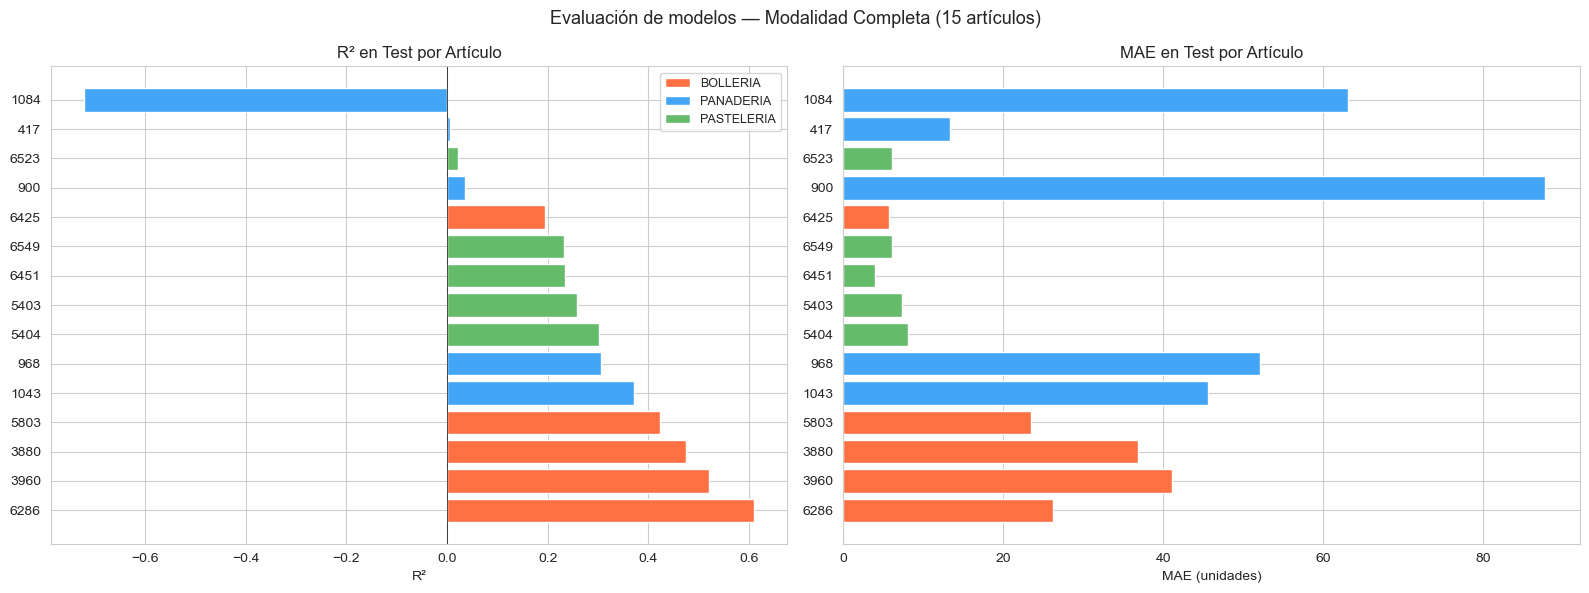

In [25]:
# Visualización de métricas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colores_fam = {row['familia']: {'BOLLERIA': '#FF7043', 'PANADERIA': '#42A5F5',
                                 'PASTELERIA': '#66BB6A'}.get(row['familia'], 'gray')
               for _, row in df_metricas.iterrows()}
bar_colors = [colores_fam[f] for f in df_metricas['familia']]

# R² test
axes[0].barh(df_metricas['articulo'].astype(str), df_metricas['r2_test'],
             color=bar_colors, edgecolor='white')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_title('R² en Test por Artículo', fontsize=12)
axes[0].set_xlabel('R²')

# MAE test
axes[1].barh(df_metricas['articulo'].astype(str), df_metricas['mae_test'],
             color=bar_colors, edgecolor='white')
axes[1].set_title('MAE en Test por Artículo', fontsize=12)
axes[1].set_xlabel('MAE (unidades)')

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF7043', label='BOLLERIA'),
    Patch(facecolor='#42A5F5', label='PANADERIA'),
    Patch(facecolor='#66BB6A', label='PASTELERIA'),
]
axes[0].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Evaluación de modelos — Modalidad Completa (15 artículos)', fontsize=13)
plt.tight_layout()
plt.show()

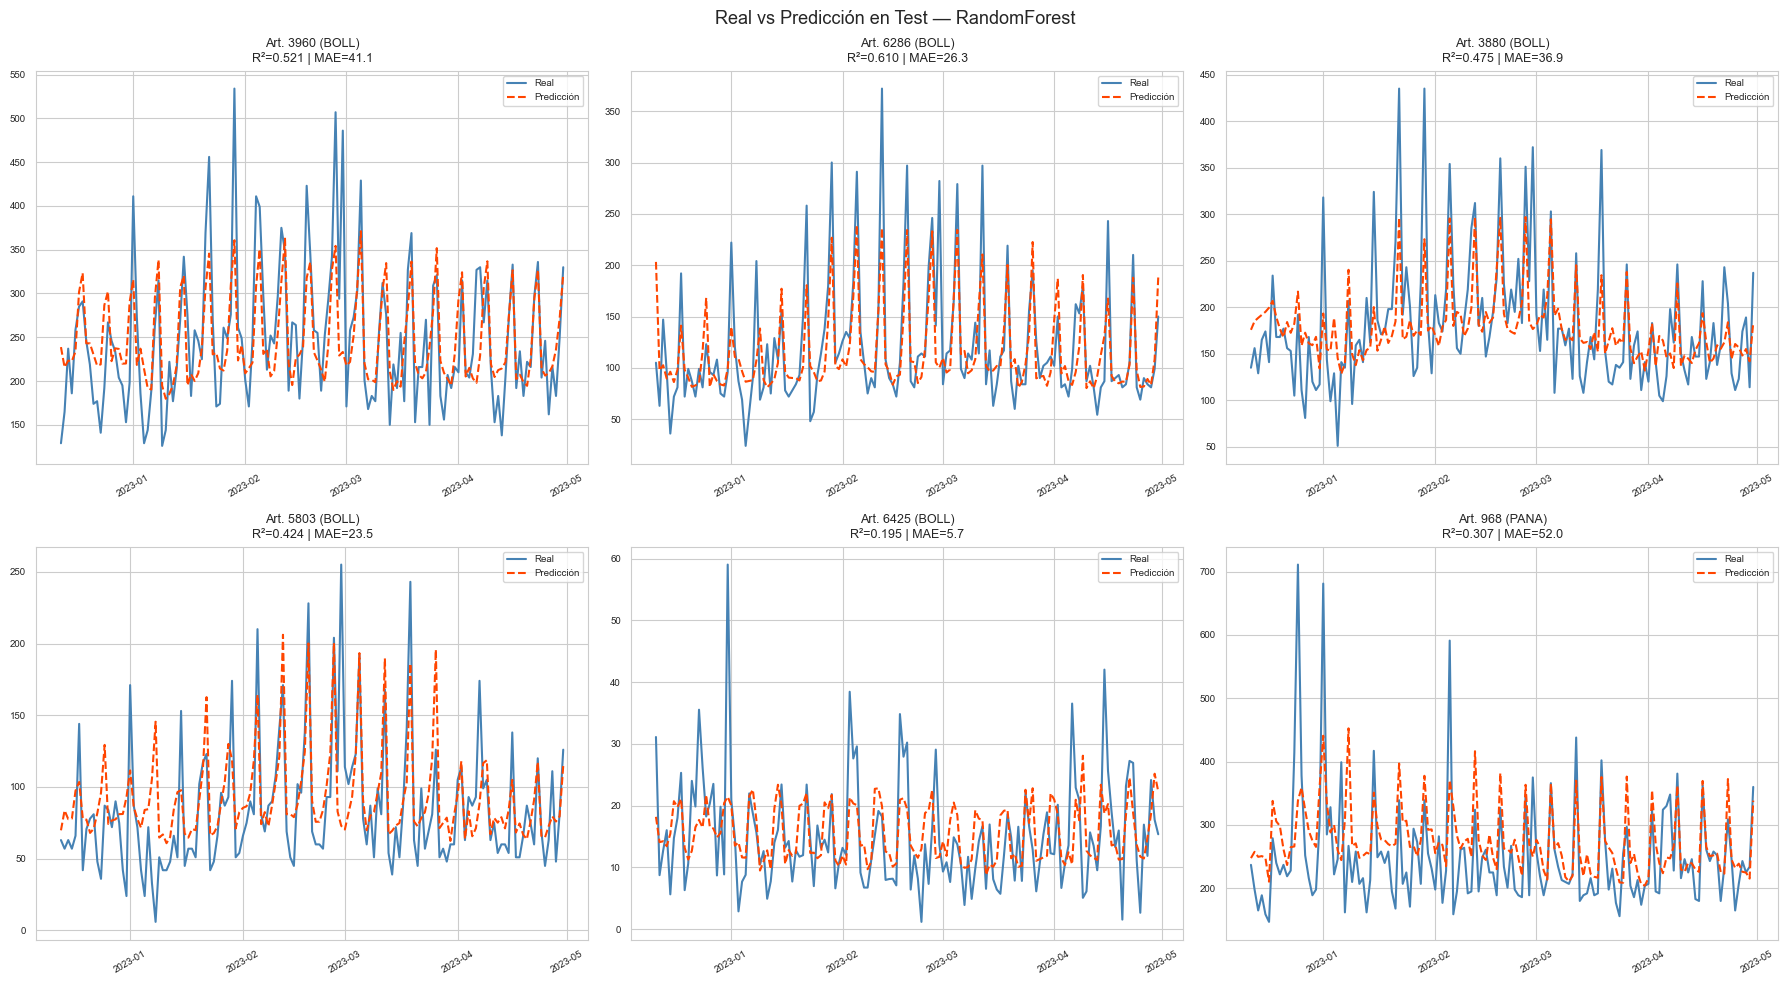

In [26]:
# Gráfico real vs predicción para los primeros 6 artículos
arts_plot = list(resultados_modelos.keys())[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, art in zip(axes.flatten(), arts_plot):
    res = resultados_modelos[art]
    fechas = res['fechas_test']
    real   = res['y_test'].values
    pred   = res['y_pred']

    ax.plot(fechas, real, label='Real',      color='steelblue', linewidth=1.5)
    ax.plot(fechas, pred, label='Predicción', color='orangered',  linewidth=1.5, linestyle='--')
    ax.set_title(f'Art. {art} ({res["metricas"]["familia"][:4]})\nR²={res["metricas"]["r2_test"]:.3f} | MAE={res["metricas"]["mae_test"]:.1f}',
                 fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Real vs Predicción en Test — RandomForest', fontsize=13)
plt.tight_layout()
plt.show()

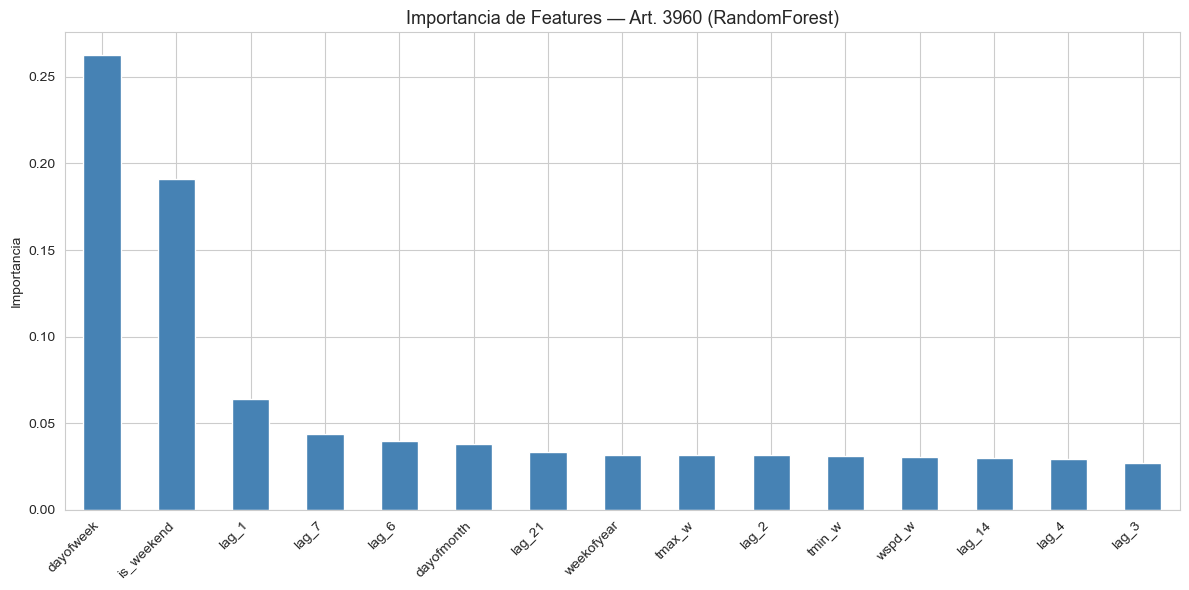

→ Los lags temporales (lag_1, lag_7) son las variables más importantes,
  seguidos por dayofweek y monthofyear — confirmando la estacionalidad detectada.


In [27]:
# Feature importance para el artículo estrella (3960)
if 3960 in resultados_modelos:
    res_3960 = resultados_modelos[3960]
    modelo_3960 = res_3960['modelo']
    feat_cols   = res_3960['feature_cols']

    importances = pd.Series(modelo_3960.feature_importances_, index=feat_cols)
    importances = importances.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    importances.head(15).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Importancia de Features — Art. 3960 (RandomForest)', fontsize=13)
    ax.set_ylabel('Importancia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('→ Los lags temporales (lag_1, lag_7) son las variables más importantes,')
    print('  seguidos por dayofweek y monthofyear — confirmando la estacionalidad detectada.')

In [28]:
# Guardar modelos y métricas
import pickle

models_path = os.path.join(BASE_DIR, 'Datathon IV', 'modelos_rf.pkl')
with open(models_path, 'wb') as f:
    pickle.dump(resultados_modelos, f)

metricas_path = os.path.join(BASE_DIR, 'Datathon IV', 'metricas_modelos.csv')
df_metricas.to_csv(metricas_path, index=False)

print(f'✓ Modelos guardados en: {models_path}')
print(f'✓ Métricas guardadas en: {metricas_path}')
print()
print('═' * 60)
print('SESIÓN 2 COMPLETADA ✓')
print('═' * 60)
print(f'  Artículos modelados  : {len(resultados_modelos)}')
print(f'  R² medio (test)      : {df_metricas["r2_test"].mean():.3f}')
print(f'  R² medio (CV)        : {df_metricas["r2_cv_mean"].mean():.3f}')
print()
print('Continuación en → Sesión_3_MLFlow.ipynb')

✓ Modelos guardados en: C:\Users\kinko\Desktop\DATATHON\DATATHONG\Datathon IV\modelos_rf.pkl
✓ Métricas guardadas en: C:\Users\kinko\Desktop\DATATHON\DATATHONG\Datathon IV\metricas_modelos.csv

════════════════════════════════════════════════════════════
SESIÓN 2 COMPLETADA ✓
════════════════════════════════════════════════════════════
  Artículos modelados  : 15
  R² medio (test)      : 0.218
  R² medio (CV)        : 0.169

Continuación en → Sesión_3_MLFlow.ipynb
